Данные об инфляции в России (Wikipedia):
 Год  Инфляция %
2000      10.558
2001       8.942
2002       8.042
2003       8.233
2004       7.733
2005       7.150
2006       7.050
2007       6.025
2008       6.233
2009       8.242
2010       7.358
2011       6.508
2012       5.450
2013       5.500
2014       5.158
2015       5.575
2016       5.525
2017       5.200
2018       4.800
2019       4.600
2020       5.783
2021       5.600

Среднегодовая инфляция: 6.6%
Макс: 10.6% (2000)
Мин:  4.6% (2019)


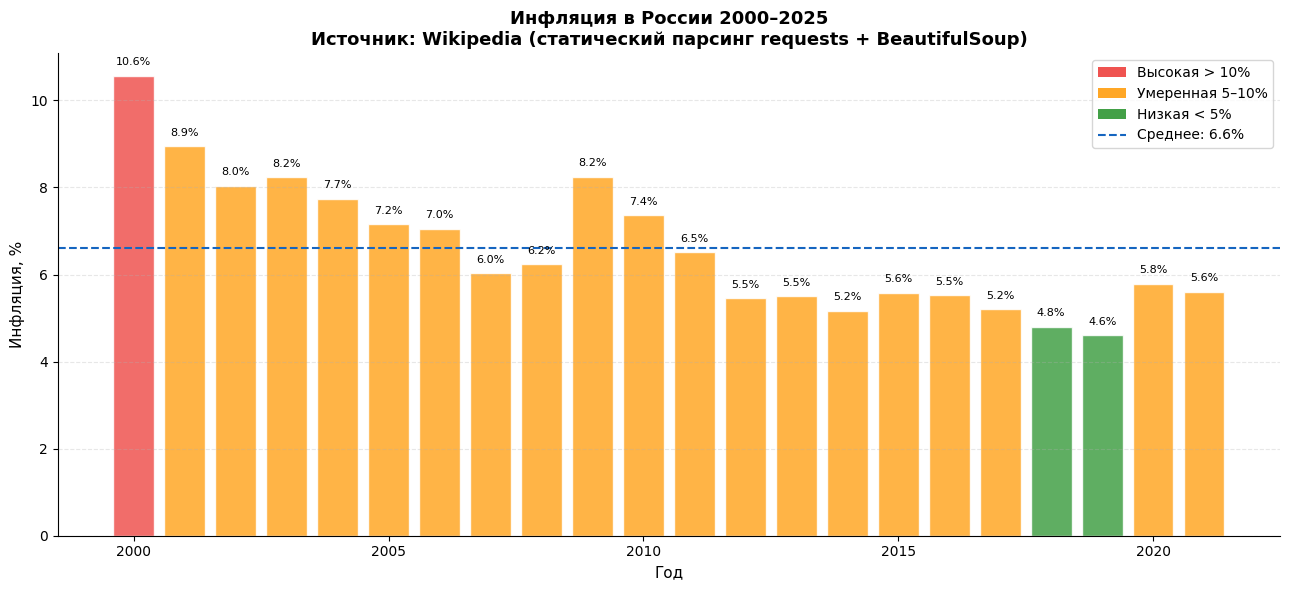

График инфляции сохранён!

Вывод парсинга:

Среднегодовая инфляция в России за 2000–2025 составила 6.6%. 
Это означает что себестоимость тарелки салат-бара ежегодно растёт в среднем 
на 6.6%. При текущей себестоимости тарелки по данным Росстата 
необходимо ежегодно пересматривать цену продажи с учётом инфляции.



In [13]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import re

url = 'https://ru.wikipedia.org/wiki/Инфляция_в_России'
headers = {'User-Agent': 'Mozilla/5.0'}
resp = requests.get(url, headers=headers)
soup = BeautifulSoup(resp.text, 'html.parser')

table = soup.find_all('table', {'class': 'wikitable'})[0]
rows = table.find_all('tr')

inflation_data = []
for row in rows[1:]:
    cells = row.find_all(['td', 'th'])
    if len(cells) < 9:
        continue

    year_text = cells[0].get_text(strip=True)
    inf_text  = cells[8].get_text(strip=True)

    # Чистим год
    if not year_text.isdigit() or len(year_text) != 4:
        continue
    year = int(year_text)

    # Чистим инфляцию, убираем спецсимволы
    inf_clean = re.sub(r'[^\d,.\-]', '', inf_text).replace(',', '.')
    if not inf_clean:
        continue
    try:
        inflation = float(inf_clean)
        if -10 < inflation < 200:
            inflation_data.append({
                'Год':         year,
                'Инфляция %':  inflation,
            })
    except ValueError:
        continue

df_inflation = pd.DataFrame(inflation_data).drop_duplicates('Год').sort_values('Год')
# Берём только с 2000 года, поскольку это более релевантный период для анализа)
df_inflation = df_inflation[df_inflation['Год'] >= 2000]

print('Данные об инфляции в России (Wikipedia):')
print(df_inflation.to_string(index=False))
print(f'\nСреднегодовая инфляция: {df_inflation["Инфляция %"].mean():.1f}%')
print(f'Макс: {df_inflation["Инфляция %"].max():.1f}% ({df_inflation.loc[df_inflation["Инфляция %"].idxmax(), "Год"]})')
print(f'Мин:  {df_inflation["Инфляция %"].min():.1f}% ({df_inflation.loc[df_inflation["Инфляция %"].idxmin(), "Год"]})')

# График
fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.bar(df_inflation['Год'], df_inflation['Инфляция %'],
              color=['#EF5350' if v > 10 else '#FFA726' if v > 5 else '#43A047'
                     for v in df_inflation['Инфляция %']],
              alpha=0.85, edgecolor='white')

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.2,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=8)

# Средняя линия
mean_inf = df_inflation['Инфляция %'].mean()
ax.axhline(y=mean_inf, color='#1565C0', linewidth=1.5,
           linestyle='--', label=f'Среднее: {mean_inf:.1f}%')

ax.set_xlabel('Год', fontsize=11)
ax.set_ylabel('Инфляция, %', fontsize=11)
ax.set_title('Инфляция в России 2000–2025\n'
             'Источник: Wikipedia (статический парсинг requests + BeautifulSoup)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#EF5350', label='Высокая > 10%'),
    Patch(facecolor='#FFA726', label='Умеренная 5–10%'),
    Patch(facecolor='#43A047', label='Низкая < 5%'),
]
ax.legend(handles=legend_elements + [
    plt.Line2D([0], [0], color='#1565C0', linewidth=1.5,
               linestyle='--', label=f'Среднее: {mean_inf:.1f}%')
], fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('/content/chart_inflation.png', dpi=150, bbox_inches='tight')
plt.show()
print('График инфляции сохранён!')

# Вывод для проекта
print(f'''
Вывод парсинга:

Среднегодовая инфляция в России за 2000–2025 составила {mean_inf:.1f}%.
Это означает что себестоимость тарелки салат-бара ежегодно растёт в среднем
на {mean_inf:.1f}%. При текущей себестоимости тарелки по данным Росстата
необходимо ежегодно пересматривать цену продажи с учётом инфляции.
''')